## 1) Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

## 2) Data Collection and Cleaning

### 2.1) Load Dataset

#### Load the Geolytix UK Open Bank Branches dataset, covering every tracked bank across the UK including both open and permanently closed branches from 2015 to 2025

In [2]:
df = pd.read_csv('geolytix_uk_open_bank_branches.csv')

In [3]:
print('Shape:', df.shape)

Shape: (12045, 18)


#### First look at the raw data by printing the first 10 rows to understand the structure of the dataset, confirm all expected columns are present, and get an initial sense of the kind of values and gaps

In [4]:
df.head(10)

,id,brand_full,brand_short,branch_name,branch_type,add_one,add_two,suburb,town,region,postcode,long_wgs84,lat_wgs84,status,close_month,close_year,open_year,po_dist
0,9381,TSB,TSB,TSB Hamilton,Branch,20 Quarry Place Shopping Arcad,NaN,Central Hamilton,Hamilton,Scotland,ML3 7BB,-4.035629,55.775277,Open,NaN,NaN,NaN,897
1,4128,Lloyds,LL,Lloyds Accrington,Branch,2 Peel Street,NaN,Hillock Vale,Accrington,North West,BB5 1EP,-2.363137,53.754043,Open,NaN,NaN,NaN,46
2,5712,Nationwide,NAI,Nationwide Hamilton,Branch,57-59 Quarry Street,NaN,Central Hamilton,Hamilton,Scotland,ML3 7AH,-4.034835,55.775039,Open,NaN,NaN,NaN,953
3,403,Barclays,BB,Barclays Local Rawtenstall,Branch,36,Bank Street,NaN,Rawtenstall,North West,BB4 7QW,-2.284940,53.702596,Closed,6.0,2022.0,NaN,145
4,1808,The Co-operative Bank,CO,Co-op Bank Burnley,Branch,60 St James St,NaN,Central Burnley,Burnley,North West,BB11 1NH,-2.243382,53.789092,Closed,6.0,2016.0,NaN,161
5,2142,Halifax,HX,Halifax Burnley,Branch,17-19 Curzon Street,Charter Walk Shopping Centre,Central Burnley,Burnley,North West,BB11 1BB,-2.244305,53.790340,Open,NaN,NaN,NaN,93
6,8140,Santander,ST,Santander Burnley 96 Sj,Branch,"96, St James Street, Burnley, Lancashire, BB11...",NaN,Central Burnley,Burnley,North West,BB11 1NJ,-2.244811,53.789421,Open,NaN,NaN,NaN,174
7,7426,Royal Bank of Scotland,RBS,RBS Burnley,Branch,NaN,NaN,Central Burnley,Burnley,North West,BB11 1NQ,-2.241635,53.788831,Closed,11.0,2018.0,NaN,205
8,6536,NatWest,NWB,NatWest Ulverston,Branch,2 Queen Street,NaN,NaN,Ulverston,North West,LA12 7AX,-3.096739,54.195800,Closed,9.0,2017.0,NaN,87
9,5390,Nationwide,NAI,Nationwide Burnley,Branch,80 St James Street,NaN,Central Burnley,Burnley,North West,BB11 1PH,-2.244315,53.789378,Open,NaN,NaN,NaN,156


### 2.2) Column Names and Data Types

#### Check data types that have been assigned to each column

In [5]:
print(df.dtypes)

id               int64
brand_full         str
brand_short        str
branch_name        str
branch_type        str
add_one            str
add_two            str
suburb             str
town               str
region             str
postcode           str
long_wgs84     float64
lat_wgs84      float64
status             str
close_month    float64
close_year     float64
open_year      float64
po_dist          int64
dtype: object


#### Output confirms all text based fields are correctly read as str and all coordinate fields as float64

### 2.3) Missing Values

#### Identify missing data across each column and assess whether the gap is acceptable

In [6]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
})

In [7]:
print(missing_summary)

             Missing Count  Missing %
id                       0       0.00
brand_full               0       0.00
brand_short              0       0.00
branch_name            120       1.00
branch_type              0       0.00
add_one                813       6.75
add_two               8133      67.52
suburb                3558      29.54
town                    23       0.19
region                  23       0.19
postcode               175       1.45
long_wgs84               0       0.00
lat_wgs84                0       0.00
status                   0       0.00
close_month           6313      52.41
close_year            5405      44.87
open_year            10402      86.36
po_dist                  0       0.00


### 2.3a) Remove records with missing values

#### Status, branch type, and region are the three columns this whole analysis leans on, so a record only gets removed if one of those three is blank. A gap in a less central field, like a missing town name, isn't a reason to lose the record. close_year is left alone here too, since it's naturally blank for branches that are still open rather than a genuine data gap

In [8]:
df = df.dropna(subset = ['status', 'branch_type', 'region'])

In [9]:
print('Shape after removing missing values:', df.shape)

Shape after removing missing values: (12022, 18)


### 2.4) Value Counts

#### Examine the three most important categorical columns in the dataset to understand the raw composition, looking at status to understand the open versus closed split, branch type to check whether all records represent permanent physical locations, and region to confirm the dataset covers all parts of the UK

In [10]:
print('Status Breakdown:')
print(df['status'].value_counts())
print()
print('Branch Type Breakdown:')
print(df['branch_type'].value_counts())
print()
print('Region Breakdown:')
print(df['region'].value_counts())

Status Breakdown:
status
Closed     6624
Open       5388
Closing      10
Name: count, dtype: int64

Branch Type Breakdown:
branch_type
Branch                     9983
Mobile Branch               837
Local Pod                   503
Banking Hub                 371
Agency                      115
Digital Services Branch      78
Local Branch                 66
Temporary Banking Hub        63
Temporary Branch              3
Head Office                   1
Cash Pod                      1
Kiosk                         1
Name: count, dtype: int64

Region Breakdown:
region
Scotland                    1637
South East                  1554
London                      1356
North West                  1244
South West                  1138
East of England              997
Yorkshire and The Humber     953
West Midlands                916
Wales                        806
East Midlands                708
North East                   435
Northern Ireland             278
Name: count, dtype: int64


#### Output shows 6,630 closed branches against 5,405 open and 10 closing Revealed 837 mobile branches recorded Confirmed all 12 UK regions are present, giving full geographic coverage

### 2.4a) Combine Closing into Closed

#### Check whether Closing branches already have a close_year value before merging them in

In [11]:
print(df[df['status'] == 'Closing'][['region', 'close_year']])

                region  close_year
905           Scotland      2025.0
3596     West Midlands      2025.0
4465             Wales      2025.0
6339            London      2025.0
7592     East Midlands      2025.0
8652     East Midlands      2025.0
9148   East of England      2025.0
11620       North West      2025.0
11665    East Midlands      2025.0
11751  East of England      2025.0


#### Closing branches are treated as closed since they have already been announced for closure

In [12]:
df['status'] = df['status'].replace('Closing', 'Closed')

In [13]:
print('Status Breakdown (Updated):')
print(df['status'].value_counts())

Status Breakdown (Updated):
status
Closed    6634
Open      5388
Name: count, dtype: int64


### 2.5) Branch Closures by Year

#### Plot all close_year values to understand the pace of branch closures, and check for any data quality issues in the process

In [14]:
closed_df = df[df['status'] == 'Closed']

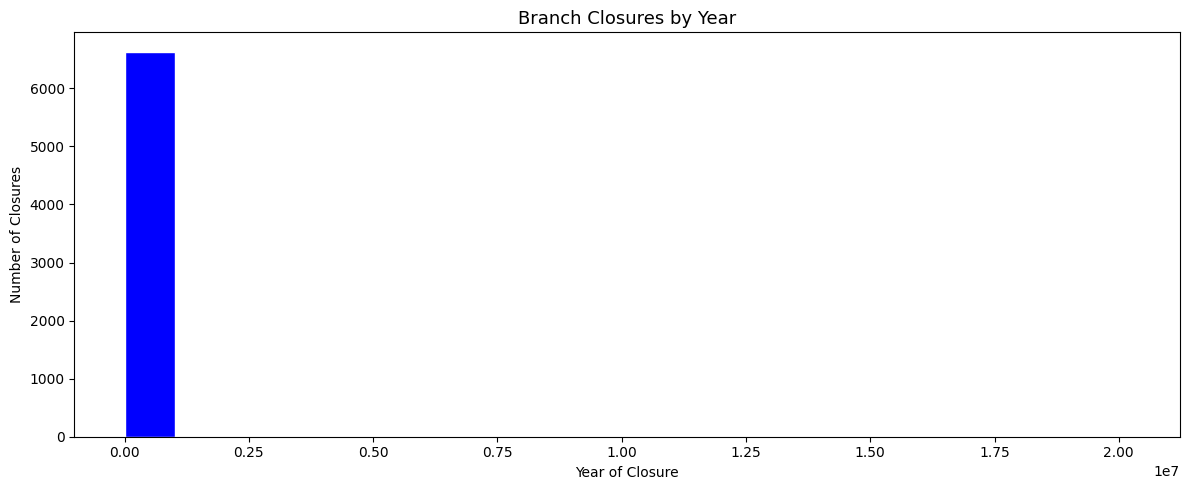

In [15]:
plt.figure(figsize = (12, 5))
plt.hist(closed_df['close_year'].dropna(), bins = 20, color = 'blue', edgecolor = 'white')
plt.title('Branch Closures by Year', fontsize = 13)
plt.xlabel('Year of Closure')
plt.ylabel('Number of Closures')
plt.tight_layout()
plt.show()

#### Output shows the x axis stretched to an extreme scale, a sign that some close_year values fall well outside a realistic range

### 2.5a) Investigating outliers

#### Sort and inspect close_year value counts to see exactly which values are pulling the axis out to an extreme scale

In [16]:
print('Close Year Value Counts Sorted:')
print(closed_df['close_year'].value_counts().sort_index())

Close Year Value Counts Sorted:
close_year
6.0              1
7.0              1
2015.0         319
2016.0         486
2017.0         808
2018.0         775
2019.0         444
2020.0         156
2021.0         804
2022.0        1055
2023.0         652
2024.0         561
2025.0         571
20220116.0       1
Name: count, dtype: int64


#### Output confirms 6, 7, and 20220116 to be anomalies

In [17]:
df = df[~df['close_year'].isin([6, 7, 20220116])]

In [18]:
print('Shape after removing close_year anomalies:', df.shape)

Shape after removing close_year anomalies: (12019, 18)


### 2.5b) Branch Closures by Year (Clean)

#### Re-plot the closures by year now that the anomalous values have been removed, to see the true closure trend

In [19]:
closed_df = df[df['status'] == 'Closed']

In [20]:
year_counts = closed_df['close_year'].dropna().astype(int).value_counts().sort_index()

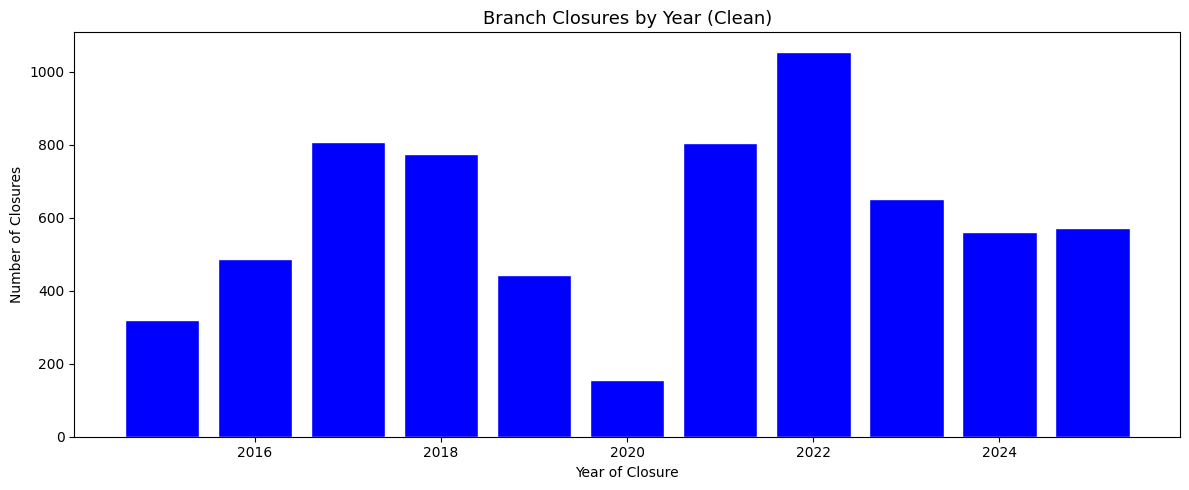

In [21]:
plt.figure(figsize = (12, 5))
plt.bar(year_counts.index, year_counts.values, color = 'blue', edgecolor = 'white')
plt.title('Branch Closures by Year (Clean)', fontsize = 13)
plt.xlabel('Year of Closure')
plt.ylabel('Number of Closures')
plt.tight_layout()
plt.show()

#### Output shows a clear closure trend: around 320 closures in 2015, rising sharply through 2017 and 2018 to over 800, dipping in 2020, surging to a peak of over 1,000 in 2022, and staying elevated through 2023 to 2025. This points to an ongoing structural withdrawal of physical banking infrastructure rather than a temporary trend

### 3.1) Overview of Banking Access

#### Keep permanent branches only, mobile branches do not count as a fixed location

In [22]:
permanent_df = df[~df['branch_type'].isin(['Mobile Branch', 'Head Office', 'Temporary Branch', 'Temporary Banking Hub'])]

#### Group by town and region together so towns with the same name in different areas are not merged

In [23]:
town_permanent = permanent_df.groupby(['town', 'region']).agg(
    total_branches = ('status', 'count'),
    closed_branches = ('status', lambda x: (x == 'Closed').sum()),
    open_branches = ('status', lambda x: (x == 'Open').sum())
).reset_index()

In [24]:
town_permanent['closure_rate'] = town_permanent['closed_branches'] / town_permanent['total_branches']

#### Summary of the town level dataset to see the typical town profile and the range across each feature

In [25]:
print('Town Level Dataset Summary:')
print(town_permanent.describe().round(2))

Town Level Dataset Summary:
       total_branches  closed_branches  open_branches  closure_rate
count         1561.00          1561.00        1561.00       1561.00
mean             7.12             4.09           3.03          0.68
std             34.89            21.82          13.22          0.29
min              1.00             0.00           0.00          0.00
25%              1.00             1.00           0.00          0.50
50%              4.00             2.00           1.00          0.67
75%              8.00             4.00           4.00          1.00
max           1326.00           833.00         493.00          1.00


### 3.2) Branch Closure Rate

#### Split towns into four closure rate bands to see what share of UK towns have lost a large part of their branches

In [26]:
bins = [0, 0.25, 0.5, 0.75, 1.00]
labels = ['0 to 25%', '25 to 50%', '50 to 75%', '75 to 100%']
town_permanent['closure_band'] = pd.cut(
    town_permanent['closure_rate'], bins = bins, labels = labels, include_lowest = True
)

In [27]:
closure_band_counts = town_permanent['closure_band'].value_counts().sort_index()

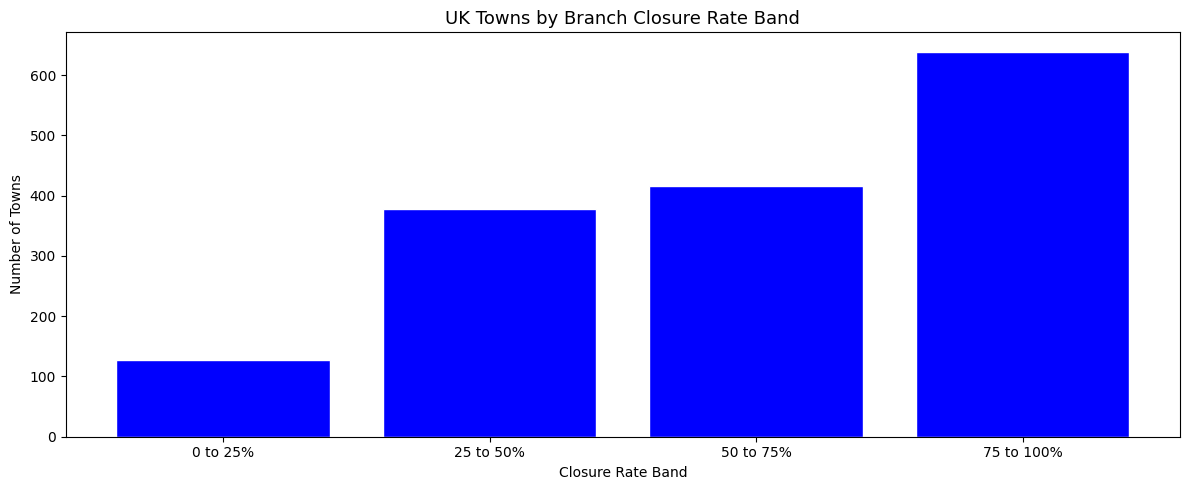

In [28]:
plt.figure(figsize = (12, 5))
plt.bar(closure_band_counts.index, closure_band_counts.values,
        color = 'blue', edgecolor = 'white')

plt.title('UK Towns by Branch Closure Rate Band', fontsize = 13)
plt.xlabel('Closure Rate Band')
plt.ylabel('Number of Towns')
plt.tight_layout()
plt.show()

### 3.3) Top 20 Towns by Branch Closures

#### Rank towns by number of closed branches, closure rate is shown alongside for context

In [29]:
top20_closure = town_permanent.nlargest(20, 'closed_branches')[
    ['town', 'closed_branches', 'total_branches', 'closure_rate']
]

In [30]:
print('Top 20 Towns by Number of Closed Branches:')
print(top20_closure.to_string(index = False))
print()

Top 20 Towns by Number of Closed Branches:
               town  closed_branches  total_branches  closure_rate
             London              833            1326      0.628205
         Birmingham               93             164      0.567073
         Manchester               86             122      0.704918
            Glasgow               80             127      0.629921
          Edinburgh               66              92      0.717391
              Leeds               66              99      0.666667
            Bristol               58              92      0.630435
          Liverpool               51              85      0.600000
         Nottingham               46              81      0.567901
          Sheffield               46              79      0.582278
            Cardiff               34              63      0.539683
          Leicester               34              59      0.576271
Newcastle Upon Tyne               33              55      0.600000
               Hull

### 4.1) Overview of Regional Banking Access

#### Group permanent branches by region to see the closure picture at a wider level than town

In [31]:
region_permanent = permanent_df.groupby('region').agg(
    total_branches = ('status', 'count'),
    closed_branches = ('status', lambda x: (x == 'Closed').sum()),
    open_branches = ('status', lambda x: (x == 'Open').sum())
).reset_index()

In [32]:
region_permanent['closure_rate'] = region_permanent['closed_branches'] / region_permanent['total_branches']

In [33]:
print('Region Level Dataset Summary:')
print(region_permanent.describe().round(2))

Region Level Dataset Summary:
       total_branches  closed_branches  open_branches  closure_rate
count           12.00            12.00          12.00         12.00
mean           926.25           531.75         394.50          0.56
std            356.92           227.77         134.41          0.04
min            277.00           137.00         140.00          0.49
25%            694.50           375.50         319.00          0.54
50%            947.50           531.00         423.00          0.56
75%           1161.50           710.00         452.00          0.59
max           1481.00           844.00         637.00          0.63


### 4.2) Regional Closure Rate

#### Sort regions by closure rate and plot them directly since there are only 12 to compare

In [34]:
region_sorted = region_permanent.sort_values('closure_rate', ascending = False)

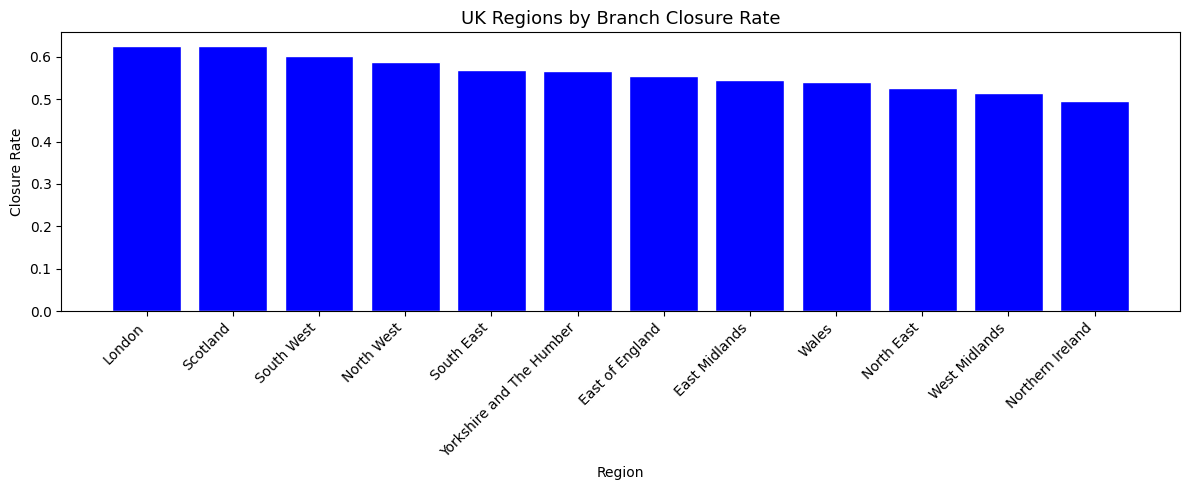

In [35]:
plt.figure(figsize = (12, 5))
plt.bar(region_sorted['region'], region_sorted['closure_rate'], color = 'blue', edgecolor = 'white')
plt.title('UK Regions by Branch Closure Rate', fontsize = 13)
plt.xlabel('Region')
plt.ylabel('Closure Rate')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

### 4.3) Regional Ranking by Closures and Rate

#### Every region has hundreds or thousands of branches, so closure rate is stable enough here to rank on directly

In [36]:
region_ranked = region_permanent.sort_values('closure_rate', ascending = False)[
    ['region', 'closed_branches', 'total_branches', 'closure_rate']
].round(3)

In [37]:
print('UK Regions Ranked by Closure Rate:')
print(region_ranked.to_string(index = False))

UK Regions Ranked by Closure Rate:
                  region  closed_branches  total_branches  closure_rate
                  London              843            1346         0.626
                Scotland              716            1147         0.624
              South West              629            1046         0.601
              North West              708            1205         0.588
              South East              844            1481         0.570
Yorkshire and The Humber              528             932         0.567
         East of England              534             963         0.555
           East Midlands              374             687         0.544
                   Wales              376             697         0.539
              North East              228             433         0.527
           West Midlands              464             901         0.515
        Northern Ireland              137             277         0.495


#### Branch closures have risen steadily since 2015, starting around 320 a year and reaching over 1,000 in 2022, staying high through 2023 to 2025, which points to a lasting structural shift rather than a short term dip. At a regional level, London and Scotland have the highest closure rates in the UK, 0.624 and 0.623, while Northern Ireland has the lowest at 0.496